In [29]:
# ============================================================================
# AUTOENCODER — DÉTECTION D'ANOMALIES
# ============================================================================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

print("=" * 60)
print("AUTOENCODER — DÉTECTION FRAUDE")
print("=" * 60)

AUTOENCODER — DÉTECTION FRAUDE


In [30]:
# 1. CHARGEMENT ET PRÉPARATION (IDENTIQUE À TON CODE)
# ============================================================================

features   = pd.read_excel(r"C:\Users\Pc\Desktop\new\features_comptes.xlsx")
operations = pd.read_excel(r"C:\Users\Pc\Desktop\new\opérations comptes.xls")

operations['compte'] = operations['compte'].astype(str)
labels = operations.groupby('compte')['anomalie'].max().reset_index()
labels.columns = ['compte', 'anomalie']

features['compte'] = features['compte'].astype(str)
df = features.merge(labels, on='compte', how='inner')

cols_exclude = ['compte', 'lieu_principal', 'anomalie']
feature_cols = [c for c in df.columns if c not in cols_exclude]

X_all = df[feature_cols].copy()
y     = df['anomalie'].values.astype(int)

# Nettoyage
X_all = X_all.replace([np.inf, -np.inf], np.nan)
X_all = X_all.fillna(X_all.median())

In [31]:
# ============================================================================
# 2. SPLIT
# ============================================================================

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_all.values, y, test_size=0.2, random_state=42, stratify=y
)

# Séparation train/validation pour optimiser le seuil
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=42, stratify=y_train_full
)

# IMPORTANT : on entraîne seulement sur les données normales
X_train_normal = X_train[y_train == 0]

print(f"Train normal : {X_train_normal.shape[0]}")
print(f"Validation   : {X_val.shape[0]} (anomalies: {y_val.sum()})")
print(f"Test         : {X_test.shape[0]} (anomalies: {y_test.sum()})")


Train normal : 1711
Validation   : 341 (anomalies: 38)
Test         : 568 (anomalies: 64)


In [32]:
# ============================================================================
# 3. NORMALISATION
# ============================================================================

scaler = StandardScaler()
X_train_normal = scaler.fit_transform(X_train_normal)
X_val  = scaler.transform(X_val)
X_test = scaler.transform(X_test)


In [33]:
# ============================================================================
# 4. AUTOENCODER MODEL
# ============================================================================
# Un encodeur qui compresse les données dans un espace latent,
# et un décodeur qui reconstruit les données originales.
# Les anomalies sont détectées via l'erreur de reconstruction.

class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


In [34]:
# ============================================================================
# 5. ENTRAÎNEMENT
# ============================================================================

device = torch.device('cpu')

model = Autoencoder(input_dim=X_train_normal.shape[1]).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

# Scheduler : réduit le lr si la loss stagne
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=20, factor=0.5,
)

X_train_tensor = torch.tensor(X_train_normal, dtype=torch.float32)

EPOCHS = 300  # Plus d'époques pour convergence
losses = []

for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, X_train_tensor)
    loss.backward()
    optimizer.step()
    scheduler.step(loss)
    losses.append(loss.item())

    if epoch % 50 == 0:
        print(f'Epoch {epoch:3d} - Loss: {loss.item():.6f}')

print(f'Loss finale : {losses[-1]:.6f}')


Epoch   0 - Loss: 1.008428
Epoch  50 - Loss: 0.595233
Epoch 100 - Loss: 0.343241
Epoch 150 - Loss: 0.218851
Epoch 200 - Loss: 0.147065
Epoch 250 - Loss: 0.106819
Loss finale : 0.094224


In [35]:
# ============================================================================
# 6. DÉTECTION ANOMALIES + OPTIMISATION DU SEUIL
# ============================================================================

model.eval()

# Erreur de reconstruction sur validation
X_val_tensor  = torch.tensor(X_val,  dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

recon_val  = model(X_val_tensor).detach().numpy()
recon_test = model(X_test_tensor).detach().numpy()

mse_val  = np.mean((X_val  - recon_val)  ** 2, axis=1)
mse      = np.mean((X_test - recon_test) ** 2, axis=1)

# Optimisation du seuil sur validation (maximise le F1)
from sklearn.metrics import f1_score
best_f1, best_threshold = 0, 0
for pct in range(70, 98):
    t = np.percentile(mse_val, pct)
    pred = (mse_val > t).astype(int)
    f1 = f1_score(y_val, pred, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t
        best_pct = pct

print(f'Meilleur seuil (validation) : percentile {best_pct}% → {best_threshold:.6f}')
print(f'F1 validation : {best_f1:.4f}')

# Application sur le test
y_pred = (mse > best_threshold).astype(int)


Meilleur seuil (validation) : percentile 89% → 0.490484
F1 validation : 0.8684


In [36]:
# ============================================================================
# 7. ÉVALUATION
# ============================================================================

roc_auc = roc_auc_score(y_test, mse)
f1      = f1_score(y_test, y_pred)

print('\nRésultats Autoencoder (amélioré)')
print(f'AUC : {roc_auc:.4f}')
print(f'F1  : {f1:.4f}')

print('\nClassification Report :')
print(classification_report(y_test, y_pred, target_names=['Normal', 'Anomalie']))



Résultats Autoencoder (amélioré)
AUC : 0.9852
F1  : 0.8444

Classification Report :
              precision    recall  f1-score   support

      Normal       0.99      0.97      0.98       504
    Anomalie       0.80      0.89      0.84        64

    accuracy                           0.96       568
   macro avg       0.89      0.93      0.91       568
weighted avg       0.97      0.96      0.96       568



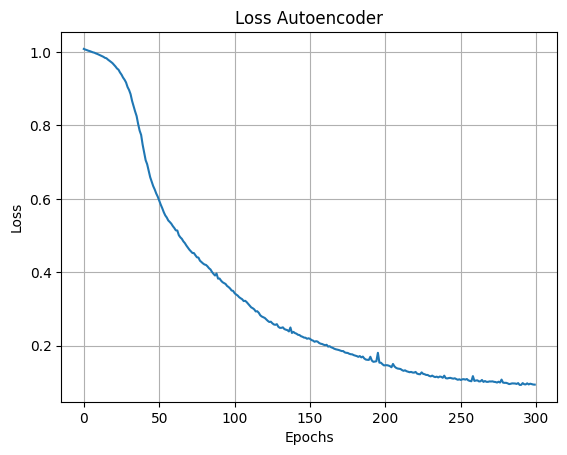

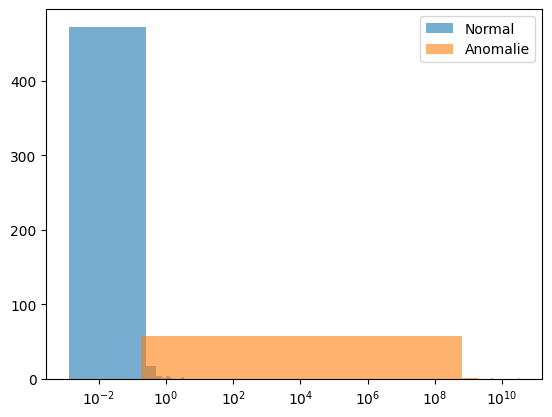

In [37]:
# ============================================================================
# 8. VISUALISATIONS
# ============================================================================

# Loss
plt.figure()
plt.plot(losses)
plt.title("Loss Autoencoder")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid()
plt.show()

# Distribution erreurs
plt.figure()
plt.hist(mse[y_test==0], bins=50, alpha=0.6, label="Normal")
plt.hist(mse[y_test==1], bins=50, alpha=0.6, label="Anomalie")
plt.xscale("log")  # 🔥 solution
plt.legend()
plt.show()